(2000, 17)


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


Epoch 1/30


/tmp/ipykernel_1661/3467231916.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1661/3467231916.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8450 - loss: 0.4900 - val_accuracy: 0.9825 - val_loss: 0.2789
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9844 - loss: 0.1881 - val_accuracy: 0.9825 - val_loss: 0.1308
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9850 - loss: 0.1058 - val_accuracy: 0.9825 - val_loss: 0.1002
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9850 - loss: 0.0863 - val_accuracy: 0.9825 - val_loss: 0.0911
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9850 - loss: 0.0780 - val_accuracy: 0.9825 - val_loss: 0.0855
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9850 - loss: 0.0723 - val_accuracy: 0.9825 - val_loss: 0.0819
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9850 - loss: 0.0682 - val_accuracy: 0.9825 - val_loss: 0.0792
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9850 - loss: 0.0653 - val_accuracy: 0.9825 - val_loss: 0.0773
Ep

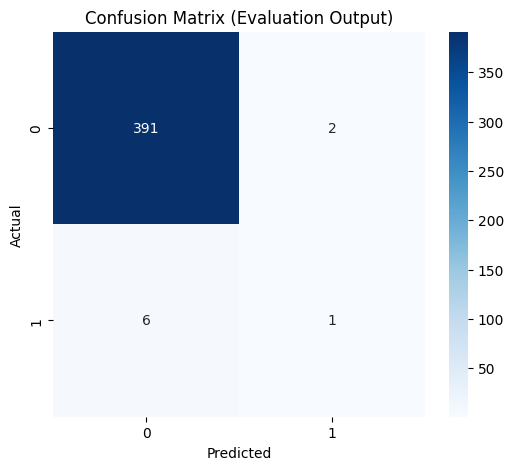


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       393
           1       0.33      0.14      0.20         7

    accuracy                           0.98       400
   macro avg       0.66      0.57      0.59       400
weighted avg       0.97      0.98      0.98       400

Experiments saved!


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 1. Loading the Data
df = pd.read_csv("customer_churn_nn.csv") # <-- CHANGE THIS
target_col = 'churn' # <-- CHANGE THIS

print(df.shape)
display(df.describe())

# Step 2. Preprocessing the data
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
        df[col] = LabelEncoder().fit_transform(df[col])
    else:
        df[col].fillna(df[col].median(), inplace=True)

X = df.drop(target_col, axis=1)
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3. Model Building
model = Sequential([
    Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 4. Training & Evaluation
# 1. Train the model and save the history
history = model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=1)

# 2. Evaluate performance
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n--- Final Testing Accuracy: {accuracy:.4f} ---")

# 3. Get predictions
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

# 4. Create and SAVE the Confusion Matrix
import os
os.makedirs('results', exist_ok=True) # Make sure the folder exists

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Evaluation Output)')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# THIS IS THE MAGIC LINE THAT SAVES THE FILE:
plt.savefig('results/evaluation_outputs.png')
plt.show()

# Print Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 5. Hyperparameter Experiments
os.makedirs('results', exist_ok=True)
results = []
for lr in [0.001, 0.01, 0.1]:
    exp_model = Sequential([Dense(32, activation='relu'), Dense(1, activation='sigmoid')])
    exp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    exp_model.fit(X_train_scaled, y_train, epochs=20, verbose=0)
    _, test_acc = exp_model.evaluate(X_test_scaled, y_test, verbose=0)
    results.append({"Learning Rate": lr, "Test Accuracy": test_acc})

pd.DataFrame(results).to_csv("results/model_comparison_table.csv", index=False)
print("Experiments saved!")